In [94]:
import ast

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

In [95]:
df = pd.read_csv("../data/experiments_results.csv")
df["fitness_history"] = df["fitness_history"].apply(ast.literal_eval)
df.head()

,dimension,benchmark,algorithm,best_fitness,best_position,fitness_history,execution_time
0,10,Ackley,PSO (JAX),0.038198,"[-0.010691370815038681, -0.01186115387827158, ...","[18.848773956298828, 16.98516845703125, 15.649...",0.002780
1,10,Ackley,PSO (JAX),0.034229,"[0.001517946133390069, -0.017054669559001923, ...","[17.928442001342773, 17.491989135742188, 17.04...",0.002625
2,10,Ackley,PSO (JAX),1.162333,"[0.0027890726923942566, -0.0118790902197361, -...","[19.47708511352539, 18.374408721923828, 17.176...",0.002609
3,10,Ackley,PSO (JAX),0.080227,"[-0.012430019676685333, -0.00635567307472229, ...","[19.0974063873291, 18.613882064819336, 18.4690...",0.002757
4,10,Ackley,PSO (JAX),1.159925,"[0.0017759697511792183, 0.007460869383066893, ...","[16.976224899291992, 15.695789337158203, 15.54...",0.002560


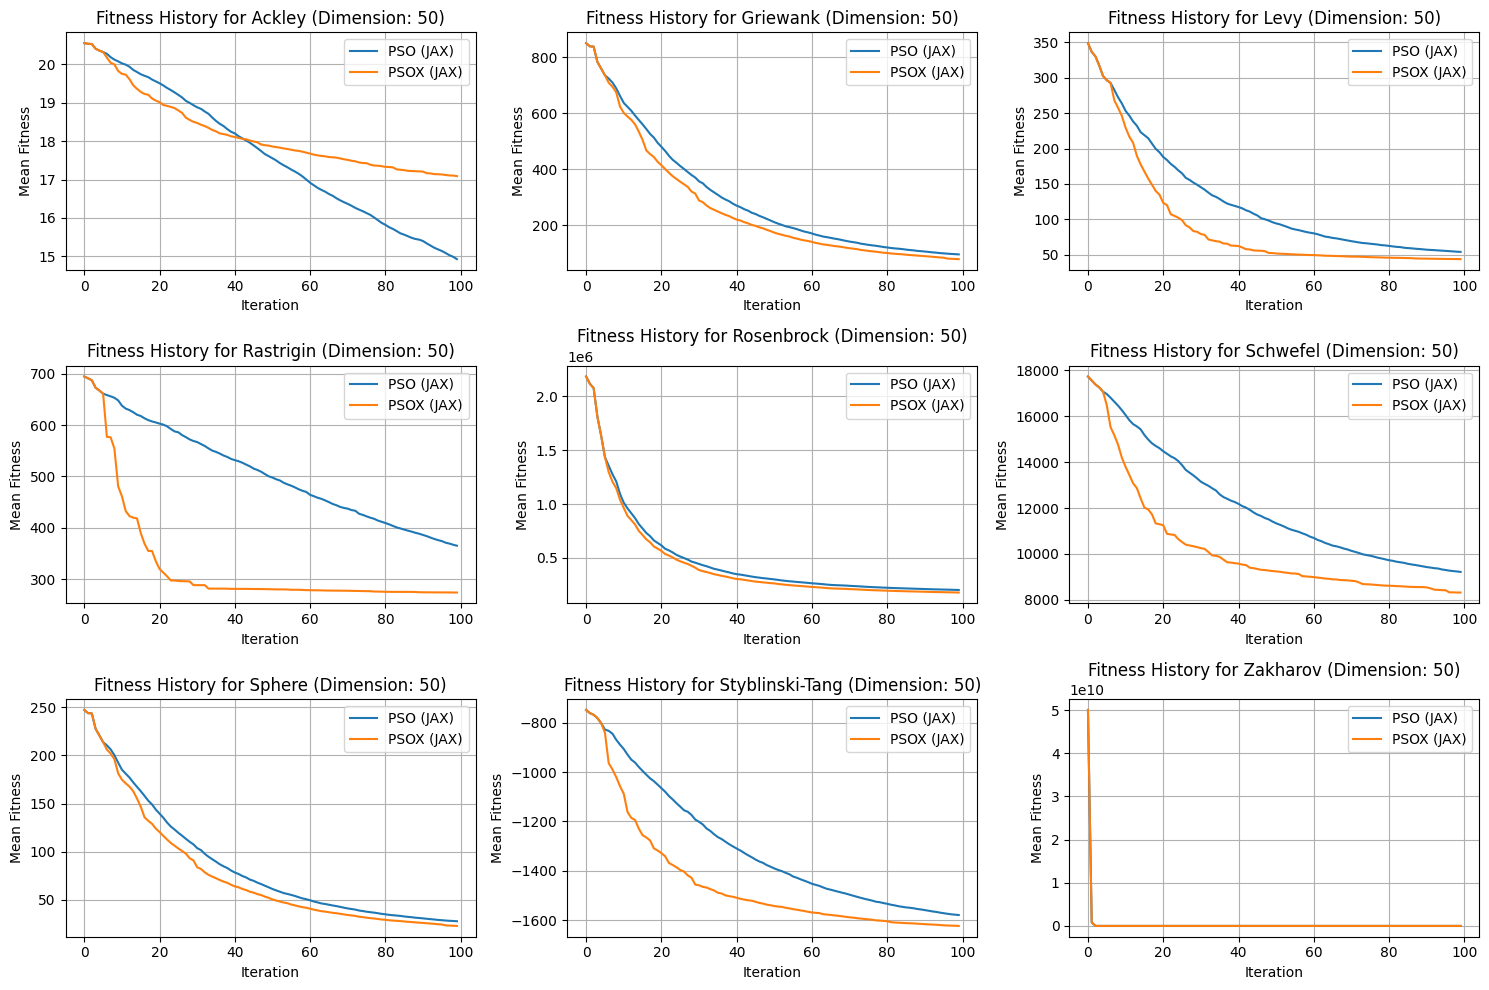

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

dimension = 50
for ax, benchmark in zip(axes, df["benchmark"].unique()):
    subset = df[(df["dimension"] == dimension) & (df["benchmark"] == benchmark)]
    for algorithm in subset["algorithm"].unique():
        alg_subset = subset[subset["algorithm"] == algorithm]
        fitness_histories = alg_subset["fitness_history"].tolist()
        mean_fitness = pd.DataFrame(fitness_histories).mean()
        ax.plot(mean_fitness, label=algorithm)
    ax.set_title(f"Fitness History for {benchmark} (Dimension: {dimension})")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Mean Fitness")
    ax.legend()
    ax.grid()

plt.tight_layout()
plt.show()

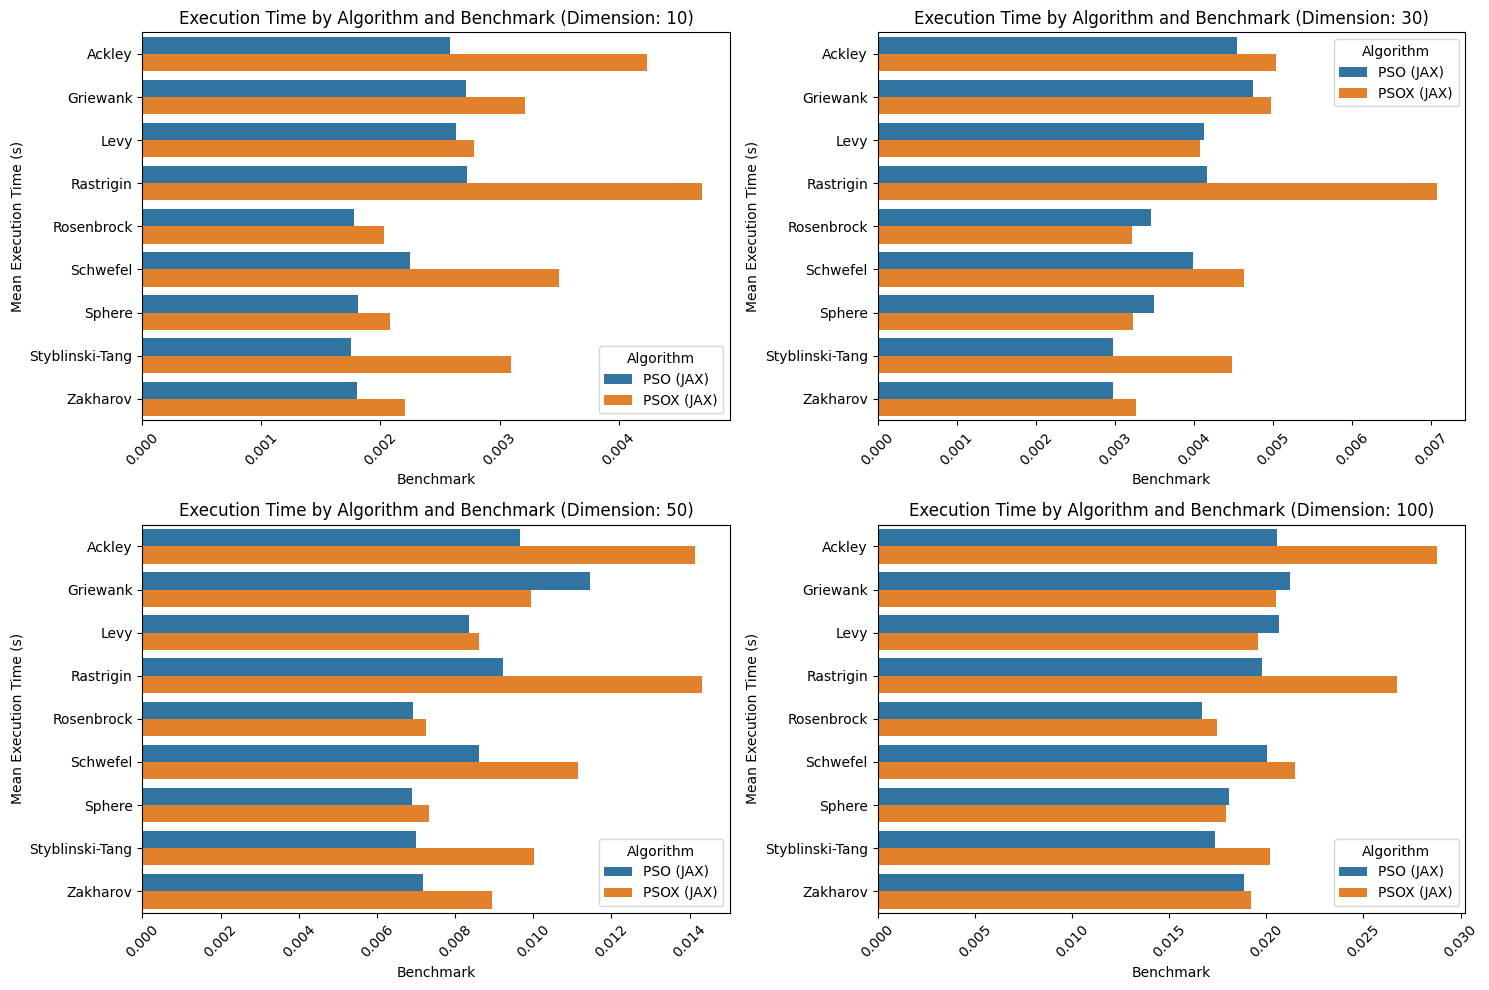

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
axes = axes.flatten()

for ax, dimension in zip(axes, df["dimension"].unique()):
    mean = (
        df[df["dimension"] == dimension]
        .groupby(["benchmark", "algorithm"])["execution_time"]
        .mean()
    )

    sns.barplot(
        x=mean.values,
        y=mean.index.get_level_values("benchmark"),
        hue=mean.index.get_level_values("algorithm"),
        orient="h",
        ax=ax,
    )
    ax.set_title(f"Execution Time by Algorithm and Benchmark (Dimension: {dimension})")
    ax.set_xlabel("Benchmark")
    ax.set_ylabel("Mean Execution Time (s)")
    ax.legend(title="Algorithm")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [98]:
algorithm_a = "PSOX (JAX)"
algorithm_b = "PSO (JAX)"

threshold = 0.05
df_filtered = df[df["algorithm"].isin([algorithm_a, algorithm_b])]

results = []
for benchmark in df_filtered["benchmark"].unique():
    for dimension in df_filtered["dimension"].unique():
        subset = df_filtered[
            (df_filtered["benchmark"] == benchmark)
            & (df_filtered["dimension"] == dimension)
        ]

        fitness_a = subset[subset["algorithm"] == algorithm_a][
            "best_fitness"
        ].to_numpy()
        fitness_b = subset[subset["algorithm"] == algorithm_b][
            "best_fitness"
        ].to_numpy()

        stat, p_value = stats.wilcoxon(fitness_a, fitness_b, alternative="two-sided")

        results.append(
            {
                "benchmark": benchmark,
                "dimension": dimension,
                f"p < {threshold}": p_value < threshold,
                "best_algorithm": algorithm_a
                if np.median(fitness_a) < np.median(fitness_b)
                else algorithm_b,
            },
        )

df_results = pd.DataFrame(results)
df_results

,benchmark,dimension,p < 0.05,best_algorithm
0,Ackley,10,True,PSOX (JAX)
1,Ackley,30,True,PSO (JAX)
2,Ackley,50,True,PSO (JAX)
3,Ackley,100,True,PSOX (JAX)
4,Griewank,10,True,PSOX (JAX)
5,Griewank,30,True,PSOX (JAX)
6,Griewank,50,True,PSOX (JAX)
7,Griewank,100,True,PSOX (JAX)
8,Levy,10,False,PSOX (JAX)
9,Levy,30,False,PSO (JAX)
